In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from datetime import datetime


# 1. 数据获取
data = pd.read_csv('data.csv.csv')

# 2. 数据预处理
# 判断缺失值
missing_values = data.isnull().sum()
print("缺失值情况：\n", missing_values)

# 处理缺失值
data = data.dropna()

# 将InvoiceDate转换为日期时间类型
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# 计算购买频次
data['CustomerID'] = data['CustomerID'].astype(int)
purchase_frequency = data.groupby('CustomerID').size().reset_index(name='Frequency')

# 计算最近消费时间（Recency）
max_date = data['InvoiceDate'].max()
recency_data = data.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_data['Recency'] = (max_date - recency_data['InvoiceDate']).dt.days

# 计算消费金额（Monetary）
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
monetary_data = data.groupby('CustomerID')['TotalPrice'].sum().reset_index()

# 更新CSV文件
data.to_csv('data.csv.csv', index=False) 

缺失值情况：
 InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
TotalPrice     0
dtype: int64


In [4]:
# 3. RFM分析
rfm = pd.merge(recency_data, purchase_frequency, on='CustomerID')
rfm = pd.merge(rfm, monetary_data, on='CustomerID')
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'TotalPrice']]
rfm

,CustomerID,Recency,Frequency,TotalPrice
0,12346,325,2,0.00
1,12347,1,182,4310.00
2,12348,74,31,1797.24
3,12349,18,73,1757.55
4,12350,309,17,334.40
...,...,...,...,...
4367,18280,277,10,180.60
4368,18281,180,7,80.82
4369,18282,7,13,176.60
4370,18283,3,756,2094.88


D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32858 (\N{CJK UNIFIED IDEOGRAPH-805A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.p

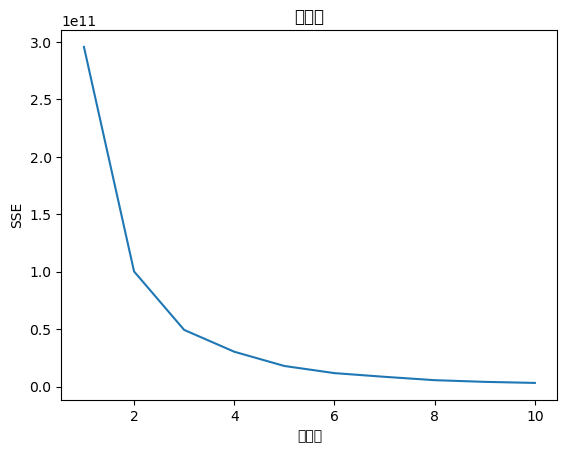

In [5]:
# 4. 确定k值（使用肘方法）
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, init='k-means++')
    kmeans.fit(rfm[['Recency', 'Frequency', 'TotalPrice']])
    sse.append(kmeans.inertia_)

# 绘制肘方法图
plt.plot(range(1, 11), sse)
plt.title('肘方法')
plt.xlabel('聚类数')
plt.ylabel('SSE')
plt.show()

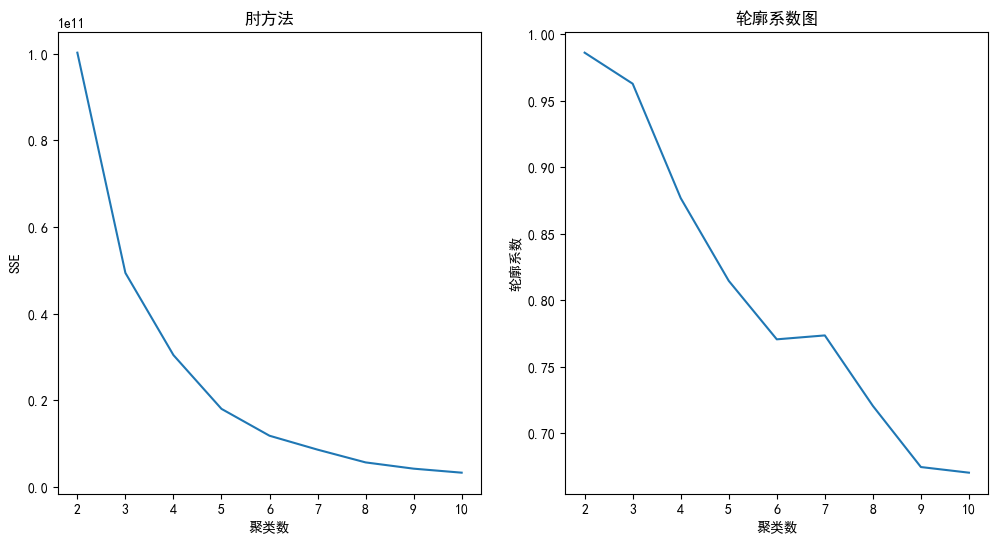

In [11]:
# 4. 确定k值（使用肘方法和轮廓系数法）
from sklearn.metrics import silhouette_score
sse = []
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, init='k-means++')
    kmeans.fit(rfm[['Recency', 'Frequency', 'TotalPrice']])
    sse.append(kmeans.inertia_)
    if k > 1:
        silhouette_scores.append(silhouette_score(rfm[['Recency', 'Frequency', 'TotalPrice']], kmeans.labels_))


# 绘制肘方法图
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), sse)
plt.title('肘方法')
plt.xlabel('聚类数')
plt.ylabel('SSE')

# 绘制轮廓系数图
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores)
plt.title('轮廓系数图')
plt.xlabel('聚类数')
plt.ylabel('轮廓系数')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.show()

In [18]:
k = 3

#9.聚类分析
kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, init='k-means++')
kmeans.fit(rfm[['Recency', 'Frequency', 'TotalPrice']])
rfm['Cluster'] = kmeans.labels_

#10.贴标签
label_mapping = {0: '低价值客户', 1: '中等价值客户', 2: '高价值客户'}
rfm['ClusterLabel'] = rfm['Cluster'].map(label_mapping)

#11.聚类可视化
# 绘制三维RFM图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['TotalPrice'], label=f'Cluster {label_mapping[cluster]}')

ax.set_xlabel('最近消费(Recency)')
ax.set_ylabel('消费频率(Frequency)')
ax.set_zlabel('消费金额(Monetary)')
ax.set_title('三维RFM客户聚类图')
ax.legend()
plt.show()

KeyError: "['TotalPrice'] not in index"

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1.读数据data,data.info()
data = pd.read_csv('data.csv.csv')
print("数据基本信息：")
data.info()

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 20.7+ MB


In [2]:
# 2. 检查重复行
duplicated_rows = data.duplicated()
print(f"重复行数量: {duplicated_rows.sum()}")
data = data[~duplicated_rows]

# 3. 检查缺失值， CID缺失删除
print("各列缺失值数量：")
print(data.isnull().sum())
data = data.dropna(subset=['CustomerID'])
data

重复行数量: 237175
各列缺失值数量：
InvoiceNo          0
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     49334
dtype: int64


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,6,12/1/2010 8:26,2.55,17850.0
1,536365,6,12/1/2010 8:26,3.39,17850.0
2,536365,8,12/1/2010 8:26,2.75,17850.0
5,536365,2,12/1/2010 8:26,7.65,17850.0
6,536365,6,12/1/2010 8:26,4.25,17850.0
...,...,...,...,...,...
541901,581587,8,12/9/2011 12:50,1.95,12680.0
541903,581587,4,12/9/2011 12:50,4.15,12680.0
541904,581587,12,12/9/2011 12:50,0.85,12680.0
541905,581587,6,12/9/2011 12:50,2.10,12680.0


In [3]:
# 4. 计算R\F\M
# 去掉退货单
data = data[data['Quantity'] > 0]

# 计算 M（消费金额）
M = data.groupby('CustomerID').apply(lambda x: (x['UnitPrice'] * x['Quantity']).sum()).reset_index(name='Monetary')

# 计算 F（消费频率）
F = data.groupby('CustomerID')['InvoiceDate'].nunique().reset_index(name='Frequency')

# 计算 R（最近一次消费时间）
# 指定日期可以设为数据中最大日期
snapshot_date = data['InvoiceDate'].max()
R = data.groupby('CustomerID')['InvoiceDate'].max().reset_index()
R['Recency'] = (snapshot_date - R['InvoiceDate']).dt.days

# 合并 RFM 数据
rfm = pd.merge(R[['CustomerID', 'Recency']], F, on='CustomerID')
rfm = pd.merge(rfm, M, on='CustomerID')
rfm

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [4]:
# 4. 计算R\F\M
# 去掉退货单
data = data[data['Quantity'] > 0]

# 将 InvoiceDate 转换为日期时间类型
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# 计算 M（消费金额）
M = data.groupby('CustomerID').apply(lambda x: (x['UnitPrice'] * x['Quantity']).sum()).reset_index(name='Monetary')

# 计算 F（消费频率）
F = data.groupby('CustomerID')['InvoiceDate'].nunique().reset_index(name='Frequency')

# 计算 R（最近一次消费时间）
# 指定日期可以设为数据中最大日期
snapshot_date = data['InvoiceDate'].max()
R = data.groupby('CustomerID')['InvoiceDate'].max().reset_index()
R['Recency'] = (snapshot_date - R['InvoiceDate']).dt.days

# 合并 RFM 数据
rfm = pd.merge(R[['CustomerID', 'Recency']], F, on='CustomerID')
rfm = pd.merge(rfm, M, on='CustomerID')
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,3125.98
2,12348.0,74,4,1399.80
3,12349.0,18,1,1209.49
4,12350.0,309,1,174.20
...,...,...,...,...
4334,18280.0,277,1,147.90
4335,18281.0,180,1,53.79
4336,18282.0,7,2,165.30
4337,18283.0,3,16,875.63


RFM 描述性统计信息：
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     91.518322     4.250749    1533.500008
std     100.009747     7.642803    6987.665691
min       0.000000     1.000000       0.000000
25%      17.000000     1.000000     221.780000
50%      50.000000     2.000000     495.610000
75%     141.000000     5.000000    1188.520000
max     373.000000   211.000000  202359.830000


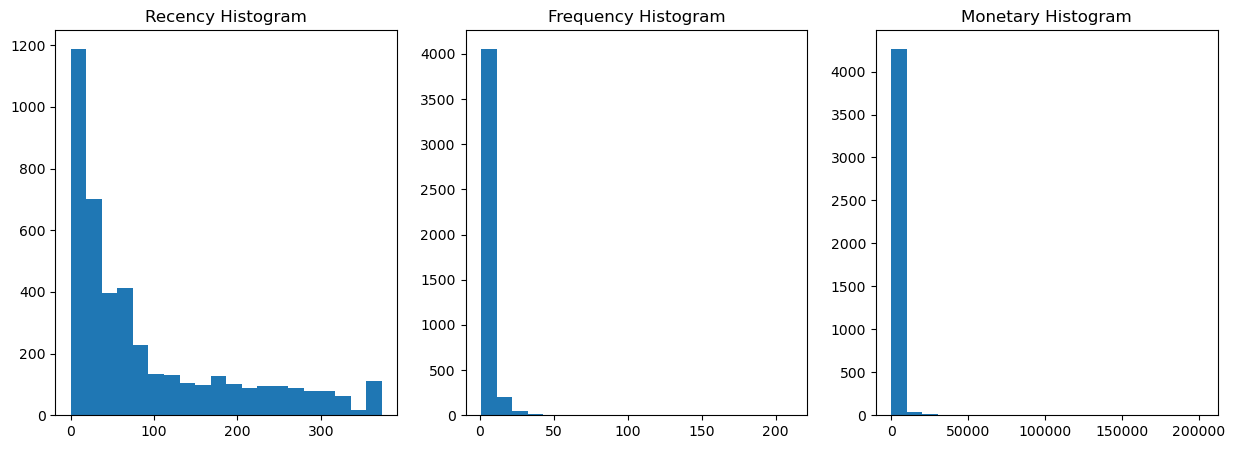

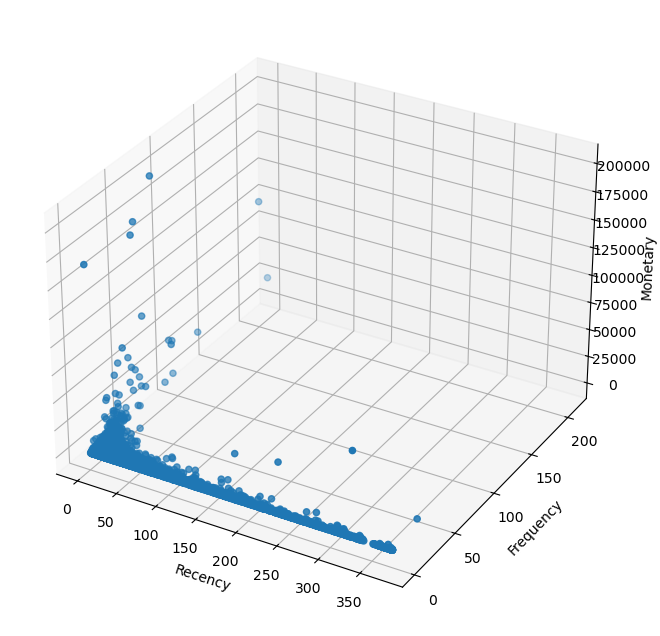

In [5]:
# 5. R\F\M 的描述性信息、可视化：直方图， 三维散点图
print("RFM 描述性统计信息：")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# 绘制直方图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(rfm['Recency'], bins=20)
axes[0].set_title('Recency Histogram')
axes[1].hist(rfm['Frequency'], bins=20)
axes[1].set_title('Frequency Histogram')
axes[2].hist(rfm['Monetary'], bins=20)
axes[2].set_title('Monetary Histogram')
plt.show()

# 绘制三维散点图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'])
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.show()

In [6]:
# 5. R\F\M 标准化处理，检查离群点
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

#离群点检测
Q1 = rfm_scaled.quantile(0.25)
Q3 = rfm_scaled.quantile(0.75)
IQR = Q3 - Q1
outliers = ((rfm_scaled < (Q1 - 1.5 * IQR)) | (rfm_scaled > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"离群点数量: {outliers.sum()}")

离群点数量: 647


In [16]:
# 5. R\F\M 标准化处理，检查离群点
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# 简单的离群点检测，可根据实际情况调整
outliers = ((rfm_scaled > 3) | (rfm_scaled < -3)).any(axis=1)
# 处理异常值
rfm_scaled['Recency'] = rfm_scaled['Recency'].clip(-3, 3)
rfm_scaled['Frequency'] = rfm_scaled['Frequency'].clip(-3, 3)
rfm_scaled['Monetary'] = rfm_scaled['Monetary'].clip(-3, 3)
print(f"离群点数量: {outliers.sum()}")
rfm = rfm[~outliers].reset_index(drop=True)  # 同步 rfm 数据框

离群点数量: 146


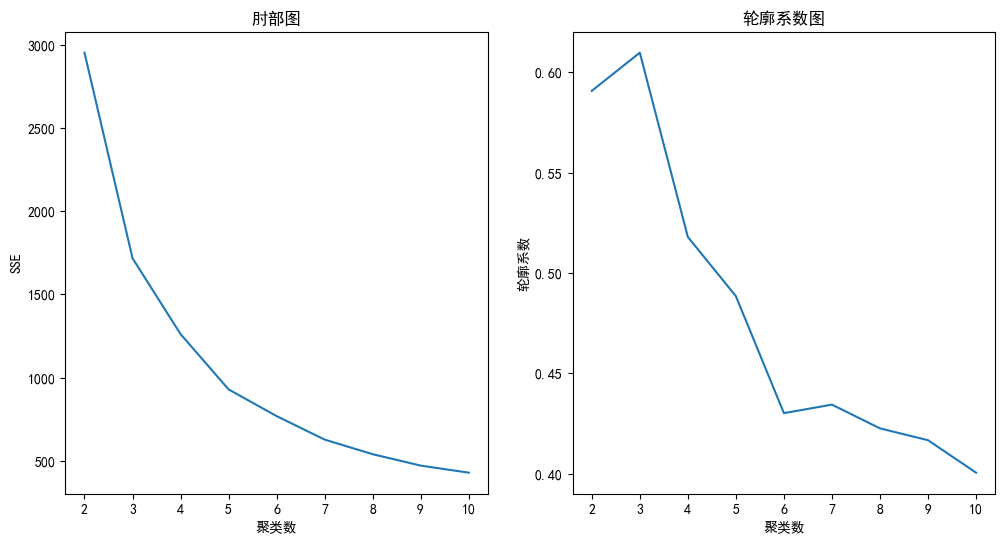

In [9]:
# 6. 确定 K
sse = []
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, init='k-means++')
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)
    if k > 1:
        silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# 绘制肘方法图
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), sse)
plt.title('肘部图')
plt.xlabel('聚类数')
plt.ylabel('SSE')

# 绘制轮廓系数图
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores)
plt.title('轮廓系数图')
plt.xlabel('聚类数')
plt.ylabel('轮廓系数')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.show()

In [10]:
k = 3

# 7. 配置模型、训练模型
kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, init='k-means++')
kmeans.fit(rfm_scaled)

# 8. 模型结果：分成几类，各类的质心，每个顾客属于哪一类
print(f"分成的类别数: {k}")
print("各类的质心：")
print(scaler.inverse_transform(kmeans.cluster_centers_))
rfm = rfm[~outliers].reset_index(drop=True)  # 如果选择删除异常值，需要同步更新 rfm 数据
rfm['Cluster'] = kmeans.labels_

分成的类别数: 3
各类的质心：
[[2.48064030e+02 1.57549578e+00 4.12396304e+02]
 [4.37288306e+01 3.41498656e+00 8.94127830e+02]
 [1.16843854e+01 1.78127885e+01 7.43524721e+03]]


ValueError: Length of values (4339) does not match length of index (4276)

In [12]:
k = 3

# 7. 配置模型、训练模型
kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, init='k-means++')
kmeans.fit(rfm_scaled)

# 8. 模型结果：分成几类，各类的质心，每个顾客属于哪一类
print(f"分成的类别数: {k}")
print("各类的质心：")
print(scaler.inverse_transform(kmeans.cluster_centers_))
rfm = rfm[~outliers].reset_index(drop=True)
rfm['Cluster'] = kmeans.labels_

分成的类别数: 3
各类的质心：
[[2.48064030e+02 1.57549578e+00 4.12396304e+02]
 [1.16843854e+01 1.78127885e+01 7.43524721e+03]
 [4.37288306e+01 3.41498656e+00 8.94127830e+02]]


C:\Users\22065\AppData\Local\Temp\ipykernel_13516\1659309668.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rfm = rfm[~outliers].reset_index(drop=True)


ValueError: Length of values (4339) does not match length of index (4213)

KeyError: 'Cluster'

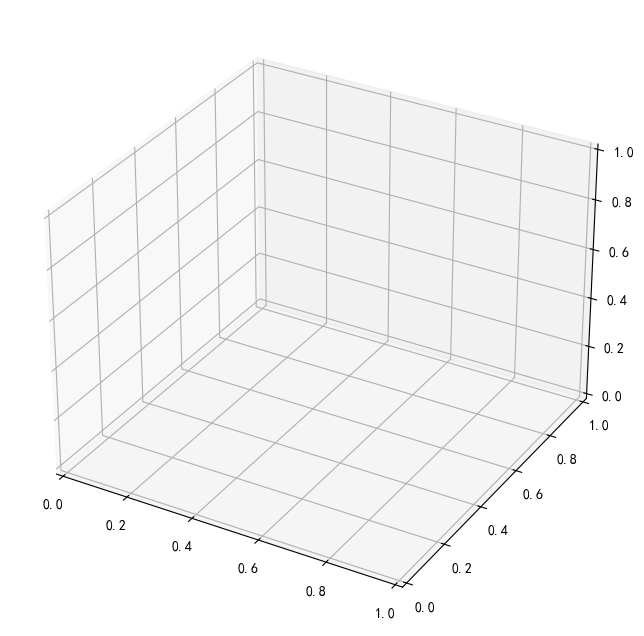

In [13]:
# 9. 模型可视化，三维R、F、M的散点图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制不同类别的散点
for cluster in range(k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'], label=f'Cluster {cluster}')

# 绘制质心
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='black', marker='x', s=200, label='Centroids')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('三维RFM客户聚类图')
ax.legend()
plt.show()

'Cluster' 列不存在，请检查前面的代码是否正确添加了该列。


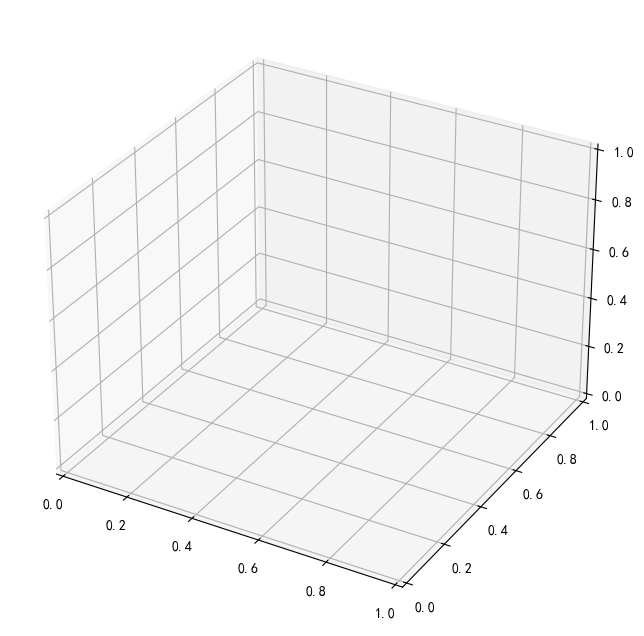

In [14]:
# 9. 模型可视化  三维R、F、M的散点图，每类不同颜色，最好也能标出质心。
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 确保 Cluster 列存在
if 'Cluster' in rfm.columns:
    # 绘制不同类别的散点
    for cluster in range(k):
        cluster_data = rfm[rfm['Cluster'] == cluster]
        ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'], label=f'Cluster {cluster}')

    # 绘制质心
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='black', marker='x', s=200, label='Centroids')

    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.set_title('三维RFM客户聚类图')
    ax.legend()
    plt.show()
else:
    print("'Cluster' 列不存在，请检查前面的代码是否正确添加了该列。")

In [15]:
# 8. 模型结果：分成几类，各类的质心，每个顾客属于哪一类
print(f"分成的类别数: {k}")
print("各类的质心：")
print(scaler.inverse_transform(kmeans.cluster_centers_))

# 确保 rfm 和 rfm_scaled 长度一致
rfm = rfm[~outliers].reset_index(drop=True)
rfm['Cluster'] = kmeans.labels_

# 9. 模型可视化  三维R、F、M的散点图，每类不同颜色，最好也能标出质心。
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 确保 Cluster 列存在
if 'Cluster' in rfm.columns:
    # 绘制不同类别的散点
    for cluster in range(k):
        cluster_data = rfm[rfm['Cluster'] == cluster]
        ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'], label=f'Cluster {cluster}')

    # 绘制质心
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='black', marker='x', s=200, label='Centroids')

    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.set_title('三维RFM客户聚类图')
    ax.legend()
    plt.show()
else:
    print("'Cluster' 列不存在，请检查前面的代码是否正确添加了该列。")

分成的类别数: 3
各类的质心：
[[2.48064030e+02 1.57549578e+00 4.12396304e+02]
 [1.16843854e+01 1.78127885e+01 7.43524721e+03]
 [4.37288306e+01 3.41498656e+00 8.94127830e+02]]


C:\Users\22065\AppData\Local\Temp\ipykernel_13516\447650805.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rfm = rfm[~outliers].reset_index(drop=True)


ValueError: Length of values (4339) does not match length of index (4150)

KeyError: 'Cluster'

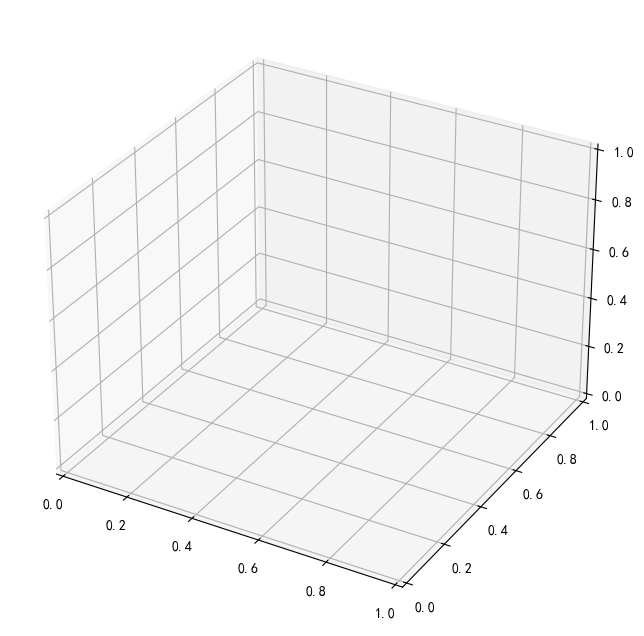

In [17]:
# 9. 模型可视化  三维R、F、M的散点图，每类不同颜色，最好也能标出质心。
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制不同类别的散点
for cluster in range(k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'], label=f'Cluster {cluster}')

# 绘制质心
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='black', marker='x', s=200, label='Centroids')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('三维RFM客户聚类图')
ax.legend()
plt.show()